In [1]:
import warnings
import pandas as pd
import pyreadr
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    accuracy_score,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
 )
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=RuntimeWarning, message='invalid value encountered in reduce')

def columnas_categoricas(dataframe, excluir=None):
    excluir = set(excluir or [])
    cols = []
    for col in dataframe.columns:
        if col in excluir:
            continue
        dtype = dataframe[col].dtype
        if (
            pd.api.types.is_object_dtype(dtype)
            or pd.api.types.is_string_dtype(dtype)
            or isinstance(dtype, pd.CategoricalDtype)
            or pd.api.types.is_bool_dtype(dtype)
        ):
            cols.append(col)
    return cols

resultado = pyreadr.read_r('listings.RData')
df = list(resultado.values())[0]
print(f"Dimensiones iniciales del dataset: {df.shape}")

numericas = df.select_dtypes(include=['number']).columns.tolist()
categoricas = columnas_categoricas(df)

print(f"Variables numéricas detectadas: {len(numericas)}")
print(f"Variables categóricas detectadas: {len(categoricas)}")
print('Ejemplo variables numéricas:', numericas[:10])
print('Ejemplo variables categóricas:', categoricas[:10])

limpio = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
 )
df['price'] = pd.to_numeric(limpio, errors='coerce')
print('Conversión de price completada.')

Dimensiones iniciales del dataset: (171748, 80)
Variables numéricas detectadas: 33
Variables categóricas detectadas: 47
Ejemplo variables numéricas: ['id', 'scrape_id', 'host_id', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm']
Ejemplo variables categóricas: ['listing_url', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_url', 'host_name', 'host_since']
Conversión de price completada.


In [2]:
df = df.replace([np.inf, -np.inf], np.nan)

faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)

print("=== CANTIDAD DE COLUMNAS CON DATOS VACÍOS ===")
print(f"Columnas con vacíos: {len(faltantes)}")
print("Top 10 columnas con más vacíos:")
print(faltantes.head(10))
print("\n" + "=" * 40 + "\n")

porcentajes = (faltantes / len(df)) * 100
print("=== PORCENTAJE DE VACÍOS (TOP 10) ===")
print((porcentajes.head(10).round(2)).astype(str) + " %")

df = df.dropna(subset=['price'])
df = df.dropna(axis=1, how='all')

numericas = df.select_dtypes(include=['number']).columns.tolist()
if 'price' in numericas:
    numericas.remove('price')

categoricas = columnas_categoricas(df, excluir=['price'])

imputador_num = SimpleImputer(strategy='median')
imputador_cat = SimpleImputer(strategy='constant', fill_value='Sin Dato')

df[numericas] = imputador_num.fit_transform(df[numericas])
df[categoricas] = imputador_cat.fit_transform(df[categoricas])

print('Filas sin precio eliminadas y faltantes imputados.')
print('Total de nulos restantes:', df.isnull().sum().sum())
print('Dimensiones luego de limpieza:', df.shape)

=== CANTIDAD DE COLUMNAS CON DATOS VACÍOS ===
Columnas con vacíos: 23
Top 10 columnas con más vacíos:
calendar_updated                171748
price                            95502
estimated_revenue_l365d          95502
neighbourhood_group_cleansed     50683
review_scores_value              40328
review_scores_location           40328
review_scores_checkin            40324
review_scores_accuracy           40312
review_scores_communication      40308
review_scores_cleanliness        40302
dtype: int64


=== PORCENTAJE DE VACÍOS (TOP 10) ===
calendar_updated                100.0 %
price                           55.61 %
estimated_revenue_l365d         55.61 %
neighbourhood_group_cleansed    29.51 %
review_scores_value             23.48 %
review_scores_location          23.48 %
review_scores_checkin           23.48 %
review_scores_accuracy          23.47 %
review_scores_communication     23.47 %
review_scores_cleanliness       23.47 %
dtype: str
Filas sin precio eliminadas y faltantes impu

1. Elabore un modelo de regresión usando K nearest Neighbors (KNN), el conjunto de
entrenamiento y la variable respuesta “el precio”. Prediga con el modelo y explique los
resultados a los que llega. Asegúrese que los conjuntos de entrenamiento y prueba sean los
mismos de las entregas anteriores para que los modelos sean comparables.

In [3]:
Y = df['price'].astype(int)
X = df.drop(columns=['price']).copy()
X = X.replace([np.inf, -np.inf], np.nan)

numericas = X.select_dtypes(include=['number']).columns.tolist()
categoricas_crudas = columnas_categoricas(X)
categoricas = [col for col in categoricas_crudas if X[col].nunique(dropna=True) < 50]

print(f"Variables numéricas usadas: {len(numericas)}")
print(f"Variables categóricas usadas (<50 categorías): {len(categoricas)}")

X[categoricas] = X[categoricas].astype(str)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
 )

preprocesador = ColumnTransformer(
    transformers=[
        ('numeros', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numericas),
        ('categorias', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categoricas)
    ]
 )

pipeline = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('regressor', KNeighborsRegressor())
 ])

print("\nEntrenando el modelo de regresión con KNN...")
pipeline.fit(X_train, Y_train)
predicciones = pipeline.predict(X_test)

rmse = root_mean_squared_error(Y_test, predicciones)
mae = mean_absolute_error(Y_test, predicciones)
r2 = r2_score(Y_test, predicciones)

print("\n=== RESULTADOS EN PRUEBA (REGRESIÓN) ===")
print(f"MAE: {mae:.2f} dólares")
print(f"RMSE: {rmse:.2f} dólares")
print(f"R2: {r2:.4f}")
print("Hiperparámetros del modelo KNN:", pipeline.named_steps['regressor'].get_params())

Variables numéricas usadas: 33
Variables categóricas usadas (<50 categorías): 16

Entrenando el modelo de regresión con KNN...

=== RESULTADOS EN PRUEBA (REGRESIÓN) ===
MAE: 303.53 dólares
RMSE: 2157.20 dólares
R2: 0.7439
Hiperparámetros del modelo KNN: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


2. Analice los resultados del modelo de regresión usando KNN. ¿Qué tan bien le fue
prediciendo? Utilice las métricas correctas.

El modelo usando regresion devolvio los siguientes valores: para el MAE obtuvimos valores de 303.53 dolares, para el MAE obtuvimos valores de 2157.20 y para el $R^{2}$ un valor de 0.7439, lo que nos deja ver que con los hiperparametros por defecto del modelo obtuvimos resultados que se pueden considerar aceptables para predecir el precio por noche de los airbnb

3. Compare los resultados con el modelo de regresión lineal, el mejor modelo de árbol de
regresión y de naive bayes que hizo en las entregas pasadas. ¿Cuál funcionó mejor? Se
sugiere apoyarse de una tabla de resumen con las mismas métricas utilizadas en las entregas
anteriores. ¿Por qué escogió esas métricas para medir el error de su modelo de regresión?

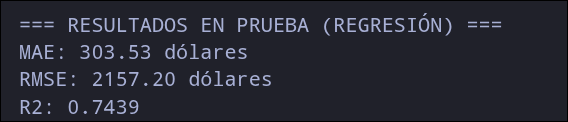

